## Импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Чтение и описание данных

Будем использовать датасет Rossmann Store Sales.

- Источник данных: репозиторий [`juniorcl/rossman-store-sales`](https://github.com/juniorcl/rossman-store-sales), исходные CSV лежат в папке `databases`.
- Локальный путь в проекте: `data/raw/rossmann`.
- Бизнес-смысл: прогноз ежедневных продаж для 1,115 магазинов Rossmann в Германии на горизонте до 6 недель.
- Тип задачи: **supervised time series / regression task**, так как для исторических дат известен целевой числовой отклик, а модель должна предсказывать будущие значения по календарным, промо- и магазинным признакам.
- Целевая переменная: **`Sales`** — дневная выручка магазина.

Файлы датасета:

- `train.csv` — обучающая таблица с историческими наблюдениями по парам магазин-дата. Содержит таргет `Sales`, количество клиентов `Customers`, календарные признаки и промо-признаки.
- `test.csv` — тестовая таблица для будущих дат. По структуре похожа на `train`, но не содержит `Sales` и `Customers`, потому что эти значения нужно прогнозировать/они неизвестны на момент прогноза.
- `store.csv` — справочник магазинов. Содержит статические свойства магазина, параметры конкуренции, тип ассортимента и признаки долгосрочной промо-кампании `Promo2`.

Поля `train.csv`:

- `Store` — идентификатор магазина.
- `DayOfWeek` — день недели.
- `Date` — календарная дата наблюдения.
- `Sales` — продажи за день; это таргет модели.
- `Customers` — количество клиентов за день; важный исторический индикатор спроса, но в реальном прогнозе может быть недоступен заранее.
- `Open` — был ли магазин открыт: `1` — открыт, `0` — закрыт.
- `Promo` — проводилась ли обычная промо-акция в этот день.
- `StateHoliday` — государственный праздник: `a` — public holiday, `b` — Easter holiday, `c` — Christmas, `0` — нет праздника.
- `SchoolHoliday` — попадала ли дата на школьные каникулы.

Поля `store.csv`:

- `Store` — идентификатор магазина для связи с `train` и `test`.
- `StoreType` — тип магазина: `a`, `b`, `c`, `d`.
- `Assortment` — уровень ассортимента: `a` — basic, `b` — extra, `c` — extended.
- `CompetitionDistance` — расстояние до ближайшего конкурента в метрах.
- `CompetitionOpenSinceMonth` и `CompetitionOpenSinceYear` — месяц и год открытия ближайшего конкурента.
- `Promo2` — участвует ли магазин в длительной повторяющейся промо-кампании.
- `Promo2SinceWeek` и `Promo2SinceYear` — неделя и год начала участия в `Promo2`.
- `PromoInterval` — месяцы, в которые повторяется кампания `Promo2`, например `Feb,May,Aug,Nov`.

In [2]:
DATA_DIR = Path("data/raw/rossmann")
if not DATA_DIR.exists():
    DATA_DIR = Path("../data/raw/rossmann")

DATA_DIR

PosixPath('../data/raw/rossmann')

In [3]:
train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"
store_path = DATA_DIR / "store.csv"

train = pd.read_csv(train_path, low_memory=False)
test = pd.read_csv(test_path, low_memory=False)
store = pd.read_csv(store_path)

print("TRAIN SHAPE:", train.shape)
print("TEST SHAPE:", test.shape)
print("STORE SHAPE:", store.shape)

print("\nTRAIN COLUMNS:")
print(train.columns.tolist())

print("\nTEST COLUMNS:")
print(test.columns.tolist())

print("\nSTORE COLUMNS:")
print(store.columns.tolist())

print("\nTRAIN HEAD:")
print(train.head())

print("\nSTORE HEAD:")
print(store.head())

print("\nTRAIN INFO:")
print(train.info())

print("\nSTORE INFO:")
print(store.info())

print("\nDATE RANGE IN TRAIN:")
train["Date"] = pd.to_datetime(train["Date"])
print(train["Date"].min(), "->", train["Date"].max())

print("\nUNIQUE STORES IN TRAIN:", train["Store"].nunique())
print("UNIQUE STORES IN STORE TABLE:", store["Store"].nunique())

print("\nMISSING VALUES IN TRAIN:")
print(train.isna().sum().sort_values(ascending=False))

print("\nMISSING VALUES IN STORE:")
print(store.isna().sum().sort_values(ascending=False))

TRAIN SHAPE: (1017209, 9)
TEST SHAPE: (41088, 8)
STORE SHAPE: (1115, 10)

TRAIN COLUMNS:
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

TEST COLUMNS:
['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

STORE COLUMNS:
['Store', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']

TRAIN HEAD:
   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday  
0

In [4]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [5]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


# Анализ данных

## Проверка временного покрытия и истории по магазинам

На этом шаге отвечаю на следующие вопросы:

- какой временной диапазон покрывает `Date`;
- сколько уникальных магазинов есть в обучающей выборке;
- сколько наблюдений приходится на один магазин;
- достаточно ли истории для построения лаговых признаков и rolling features.

In [6]:
# Временной диапазон обучающей выборки
train = train.sort_values(["Store", "Date"]).copy()

min_date = train["Date"].min()
max_date = train["Date"].max()
date_range_days = (max_date - min_date).days + 1

print(f"Date range: {min_date.date()} -> {max_date.date()}")
print(f"Calendar coverage: {date_range_days} days")

# Число уникальных магазинов
unique_train_stores = train["Store"].nunique()
unique_store_rows = store["Store"].nunique()

print(f"Unique stores in train: {unique_train_stores}")
print(f"Unique stores in store table: {unique_store_rows}")

# Число наблюдений на магазин
observations_per_store = (
    train.groupby("Store")
    .agg(
        observations=("Date", "size"),
        first_date=("Date", "min"),
        last_date=("Date", "max"),
        active_sales_days=("Sales", lambda x: (x > 0).sum()),
    )
    .assign(calendar_span_days=lambda x: (x["last_date"] - x["first_date"]).dt.days + 1)
)

print("\nObservations per store summary:")
display(observations_per_store["observations"].describe())

print("\nStores with the shortest history:")
display(observations_per_store.sort_values("observations").head(10))

# Проверка достаточности истории для лагов и rolling features
# Для rolling mean с лагом 1 нужно минимум max_lag + max_window наблюдений на магазин.
lag_periods = [1, 7, 14, 28]
rolling_windows = [7, 14, 28]
min_required_history = max(lag_periods) + max(rolling_windows)

observations_per_store["has_enough_history_for_lags_rolling"] = (
    observations_per_store["observations"] >= min_required_history
)

stores_with_enough_history = observations_per_store["has_enough_history_for_lags_rolling"].sum()
stores_without_enough_history = unique_train_stores - stores_with_enough_history

print(f"\nCandidate lags: {lag_periods}")
print(f"Candidate rolling windows: {rolling_windows}")
print(f"Minimum required observations per store: {min_required_history}")
print(
    "Stores with enough history: "
    f"{stores_with_enough_history} / {unique_train_stores} "
    f"({stores_with_enough_history / unique_train_stores:.1%})"
)
print(f"Stores without enough history: {stores_without_enough_history}")

Date range: 2013-01-01 -> 2015-07-31
Calendar coverage: 942 days
Unique stores in train: 1115
Unique stores in store table: 1115

Observations per store summary:


count    1115.000000
mean      912.295067
std        67.729422
min       758.000000
25%       942.000000
50%       942.000000
75%       942.000000
max       942.000000
Name: observations, dtype: float64


Stores with the shortest history:


,observations,first_date,last_date,active_sales_days,calendar_span_days
Store,,,,,
485,758,2013-01-01,2015-07-31,622,942
172,758,2013-01-01,2015-07-31,622,942
174,758,2013-01-01,2015-07-31,622,942
974,758,2013-01-01,2015-07-31,622,942
706,758,2013-01-01,2015-07-31,622,942
181,758,2013-01-01,2015-07-31,623,942
183,758,2013-01-01,2015-07-31,611,942
710,758,2013-01-01,2015-07-31,622,942
711,758,2013-01-01,2015-07-31,623,942



Candidate lags: [1, 7, 14, 28]
Candidate rolling windows: [7, 14, 28]
Minimum required observations per store: 56
Stores with enough history: 1115 / 1115 (100.0%)
Stores without enough history: 0


- 1115 магазинов с 942 значениями по дням - пока что достаточно и для baseline, и даже для какой-то более сложной модельки;
- видим, что некотрые магазины имеют меньше наблюдений, однако уже четвертной квантиль дает 942, значит таких магазинов немного;
- Истории достаточно для определения lag(7/14/28) и rolling mean(7/14/28) для каждого магазина.

In [7]:
print('Доля магазинов с наблюдениями меньше 942:', observations_per_store.loc[observations_per_store["observations"] < 942].shape[0]/unique_train_stores*100, '%')
print('Доля магазинов с наблюдениями меньше 780:', observations_per_store.loc[observations_per_store["observations"] < 780].shape[0]/unique_train_stores*100, '%')

Доля магазинов с наблюдениями меньше 942: 16.233183856502244 %
Доля магазинов с наблюдениями меньше 780: 16.143497757847534 %


Работать с магазинами, у которых не одинаковое количество замеров, не очень комфортно, но обрезать все магазины до общей короткой истории тоже не стоит: так мы потеряем много валидных наблюдений.

Для текущей цели EDA лучше не удалять эти магазины и не дополнять их синтетикой. Сначала нужно понять структуру отсутствующих наблюдений: это случайные пропуски, отдельные магазины с поздним стартом, закрытия на конкретный период или системный блок по датам. Если пропуски локализованы во времени, то на этапе моделирования можно будет использовать признаки доступности лагов, `min_periods` в rolling features и аккуратную валидацию по времени, не выбрасывая всю историю остальных магазинов.

Проверим, какие пары `Store`-`Date` отсутствуют относительно полной календарной сетки. Это поможет понять, нужно ли обрезать историю, фильтровать отдельные периоды или оставить данные как есть для дальнейшего feature engineering.

Expected rows for full Store x Date grid: 1,050,330
Actual rows in train: 1,017,209
Missing Store-Date rows: 33,121 (3.15%)
Stores with at least one missing date: 181
Dates with at least one missing store: 185

Distribution of missing dates per store:


count    181.000000
mean     182.988950
std       13.602283
min        1.000000
25%      184.000000
50%      184.000000
75%      184.000000
max      184.000000
Name: missing_dates, dtype: float64


Missing dates per store value counts:


,stores
missing_dates,
1,1
184,180



Top dates by number of missing stores:


,missing_stores
Date,
2014-09-30,180
2014-11-04,180
2014-10-26,180
2014-10-27,180
2014-10-28,180
2014-10-29,180
2014-10-30,180
2014-10-31,180
2014-11-01,180



Missing rows by day of week:


,missing_rows
DayOfWeek,
1,4680
2,4861
3,4860
4,4680
5,4680
6,4680
7,4680



Missing rows by month:


,missing_rows
YearMonth,
2013-01,1
2014-07,5580
2014-08,5580
2014-09,5400
2014-10,5580
2014-11,5400
2014-12,5580


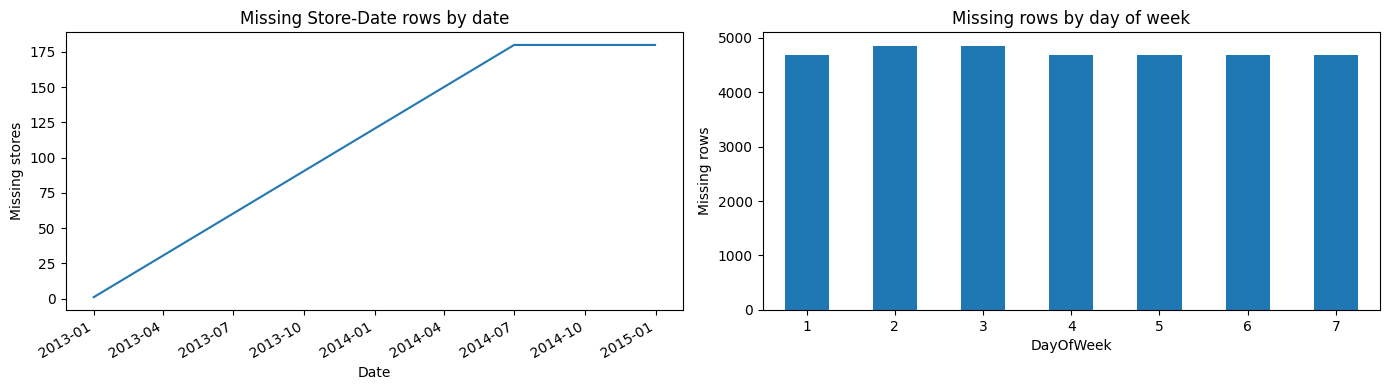

In [8]:
all_dates = pd.date_range(train["Date"].min(), train["Date"].max(), freq="D")
all_stores = np.sort(train["Store"].unique())

full_calendar_index = pd.MultiIndex.from_product(
    [all_stores, all_dates],
    names=["Store", "Date"],
)

observed_index = pd.MultiIndex.from_frame(train[["Store", "Date"]])
missing_index = full_calendar_index.difference(observed_index)

missing_observations = missing_index.to_frame(index=False)
missing_observations["DayOfWeek"] = missing_observations["Date"].dt.dayofweek + 1
missing_observations["YearMonth"] = missing_observations["Date"].dt.to_period("M")

expected_rows = len(full_calendar_index)
actual_rows = len(train)
missing_rows = len(missing_observations)

print(f"Expected rows for full Store x Date grid: {expected_rows:,}")
print(f"Actual rows in train: {actual_rows:,}")
print(f"Missing Store-Date rows: {missing_rows:,} ({missing_rows / expected_rows:.2%})")
print(f"Stores with at least one missing date: {missing_observations['Store'].nunique()}")
print(f"Dates with at least one missing store: {missing_observations['Date'].nunique()}")

missing_by_store = missing_observations.groupby("Store").size().rename("missing_dates")
missing_by_date = missing_observations.groupby("Date").size().rename("missing_stores")
missing_by_dayofweek = (
    missing_observations.groupby("DayOfWeek")
    .size()
    .rename("missing_rows")
    .reindex(range(1, 8), fill_value=0)
)
missing_by_month = missing_observations.groupby("YearMonth").size().rename("missing_rows")

print("\nDistribution of missing dates per store:")
display(missing_by_store.describe())

print("\nMissing dates per store value counts:")
display(missing_by_store.value_counts().sort_index().to_frame("stores"))

print("\nTop dates by number of missing stores:")
display(missing_by_date.sort_values(ascending=False).head(15).to_frame())

print("\nMissing rows by day of week:")
display(missing_by_dayofweek.to_frame())

print("\nMissing rows by month:")
display(missing_by_month.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

missing_by_date.plot(ax=axes[0], title="Missing Store-Date rows by date")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Missing stores")

missing_by_dayofweek.plot(kind="bar", ax=axes[1], title="Missing rows by day of week")
axes[1].set_xlabel("DayOfWeek")
axes[1].set_ylabel("Missing rows")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [9]:
if missing_rows == 0:
    print("No missing Store-Date rows in the full calendar grid.")
else:
    most_common_missing_count = missing_by_date.value_counts().idxmax()
    dates_with_common_gap = missing_by_date[missing_by_date == most_common_missing_count]
    stores_with_common_gap = missing_by_store[missing_by_store == len(dates_with_common_gap)]

    print("Main missingness pattern:")
    print(
        f"- {len(dates_with_common_gap)} dates have exactly "
        f"{most_common_missing_count} missing stores"
    )
    print(
        f"- date range for this pattern: "
        f"{dates_with_common_gap.index.min().date()} -> "
        f"{dates_with_common_gap.index.max().date()}"
    )
    print(
        f"- {len(stores_with_common_gap)} stores miss exactly "
        f"{len(dates_with_common_gap)} dates"
    )

Main missingness pattern:
- 184 dates have exactly 180 missing stores
- date range for this pattern: 2014-07-01 -> 2014-12-31
- 180 stores miss exactly 184 dates


### Вывод по блоку

- В train доступны данные за период **2013-01-01 — 2015-07-31**: всего **942 календарных дня**.
- В train и store одинаковое количество магазинов: **1115**, значит справочник `store` покрывает все магазины из обучающей выборки.
- Полная сетка `Store × Date` должна содержать **1,050,330** строк, фактически в train — **1,017,209** строк. Отсутствует **33,121 строка**, то есть около **3.15%**.
- У **181 магазина** есть хотя бы одна пропущенная дата. Основной паттерн пропусков системный: **180 магазинов отсутствуют с 2014-07-01 по 2014-12-31**, всего **184 дня**.
- По дням недели пропуски распределены почти равномерно, а по месяцам почти полностью сосредоточены во втором полугодии **2014 года**. Значит, это не случайный шум, а структурный пропуск по периоду/группе магазинов.
- Около **16.2% магазинов** имеют меньше 942 наблюдений, но уже нижний квартиль по числу наблюдений равен полному периоду, значит большинство магазинов имеют полную историю.
- Удалять магазины с неполной историей или обрезать все магазины до общего короткого периода не стоит: так потеряется много полезных наблюдений.
- Для моделирования истории достаточно для признаков `lag(7/14/28)` и `rolling mean(7/14/28)`. Для неполных рядов лучше использовать `min_periods`, флаги доступности лагов и аккуратную time-based validation.

## Data quality checks

Проверим качество данных перед feature engineering:

- пропуски в `train`, `test`, `store`;
- дубликаты строк и ключей;
- неконсистентные значения в категориальных и числовых полях;
- закрытые магазины и нулевые продажи;
- пропуски в полях конкуренции и `Promo2`;
- возможные выбросы в `Sales`.

In [10]:
def missing_report(df: pd.DataFrame) -> pd.DataFrame:
    report = pd.DataFrame(
        {
            "missing_count": df.isna().sum(),
            "missing_share": df.isna().mean(),
            "dtype": df.dtypes.astype(str),
        }
    )
    return report.sort_values("missing_count", ascending=False)

print("Missing values in train:")
display(missing_report(train))

print("Missing values in test:")
display(missing_report(test))

print("Missing values in store:")
display(missing_report(store))

Missing values in train:


,missing_count,missing_share,dtype
Store,0,0.0,int64
DayOfWeek,0,0.0,int64
Date,0,0.0,datetime64[us]
Sales,0,0.0,int64
Customers,0,0.0,int64
Open,0,0.0,int64
Promo,0,0.0,int64
StateHoliday,0,0.0,str
SchoolHoliday,0,0.0,int64


Missing values in test:


,missing_count,missing_share,dtype
Open,11,0.000268,float64
Id,0,0.000000,int64
Store,0,0.000000,int64
DayOfWeek,0,0.000000,int64
Date,0,0.000000,str
Promo,0,0.000000,int64
StateHoliday,0,0.000000,str
SchoolHoliday,0,0.000000,int64


Missing values in store:


,missing_count,missing_share,dtype
Promo2SinceWeek,544,0.487892,float64
Promo2SinceYear,544,0.487892,float64
PromoInterval,544,0.487892,str
CompetitionOpenSinceMonth,354,0.317489,float64
CompetitionOpenSinceYear,354,0.317489,float64
CompetitionDistance,3,0.002691,float64
Store,0,0.000000,int64
StoreType,0,0.000000,str
Assortment,0,0.000000,str
Promo2,0,0.000000,int64


In [11]:
# Детальный разбор пропусков в полях конкуренции и Promo2
store_missing_focus_cols = [
    "CompetitionDistance",
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",
    "Promo2SinceWeek",
    "Promo2SinceYear",
    "PromoInterval",
]

display(missing_report(store[store_missing_focus_cols]))

competition_missing_report = pd.DataFrame(
    [
        {
            "condition": "CompetitionDistance is missing",
            "stores": store["CompetitionDistance"].isna().sum(),
        },
        {
            "condition": "CompetitionOpenSinceMonth is missing",
            "stores": store["CompetitionOpenSinceMonth"].isna().sum(),
        },
        {
            "condition": "CompetitionOpenSinceYear is missing",
            "stores": store["CompetitionOpenSinceYear"].isna().sum(),
        },
        {
            "condition": "CompetitionOpenSinceMonth and CompetitionOpenSinceYear are both missing",
            "stores": (
                store["CompetitionOpenSinceMonth"].isna()
                & store["CompetitionOpenSinceYear"].isna()
            ).sum(),
        },
        {
            "condition": "CompetitionDistance exists, but competition open date is incomplete",
            "stores": (
                store["CompetitionDistance"].notna()
                & (
                    store["CompetitionOpenSinceMonth"].isna()
                    | store["CompetitionOpenSinceYear"].isna()
                )
            ).sum(),
        },
    ]
)

display(competition_missing_report)

promo2_missing_report = (
    store.groupby("Promo2")[["Promo2SinceWeek", "Promo2SinceYear", "PromoInterval"]]
    .apply(lambda x: x.isna().sum())
    .rename_axis(index="Promo2")
)

display(promo2_missing_report)

print("Stores with missing CompetitionDistance:")
display(store.loc[store["CompetitionDistance"].isna()])

print("Уникальные значения CompetitionOpenSinceMonth", store["CompetitionOpenSinceMonth"].unique())
print("Уникальные значения CompetitionOpenSinceYear", store["CompetitionOpenSinceYear"].unique())
print("Количество строк с пропущенными CompetitionOpenSinceMonth и CompetitionOpenSinceYear", store.loc[store["CompetitionOpenSinceMonth"].isna() & store["CompetitionOpenSinceYear"].isna(), "Store"].count())

print("Уникальные значения Promo2SinceWeek", store["Promo2SinceWeek"].unique())
print("Уникальные значения Promo2SinceYear", store["Promo2SinceYear"].unique())
print("Уникальные значения PromoInterval", store["PromoInterval"].unique())
print("Количество строк с пропущенными Promo2SinceWeek, Promo2SinceYear и PromoInterval и Promo2 = 0",
    store.loc[
        store["Promo2SinceWeek"].isna()
        & store["Promo2SinceYear"].isna()
        & store["PromoInterval"].isna()
        & (store["Promo2"] == 0),
        "Store"
    ].count()
)



,missing_count,missing_share,dtype
Promo2SinceWeek,544,0.487892,float64
Promo2SinceYear,544,0.487892,float64
PromoInterval,544,0.487892,str
CompetitionOpenSinceMonth,354,0.317489,float64
CompetitionOpenSinceYear,354,0.317489,float64
CompetitionDistance,3,0.002691,float64


,condition,stores
0,CompetitionDistance is missing,3
1,CompetitionOpenSinceMonth is missing,354
2,CompetitionOpenSinceYear is missing,354
3,CompetitionOpenSinceMonth and CompetitionOpenS...,354
4,"CompetitionDistance exists, but competition op...",351


,Promo2SinceWeek,Promo2SinceYear,PromoInterval
Promo2,,,
0,544,544,544
1,0,0,0


Stores with missing CompetitionDistance:


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


Уникальные значения CompetitionOpenSinceMonth [ 9. 11. 12.  4. 10.  8. nan  3.  6.  5.  1.  2.  7.]
Уникальные значения CompetitionOpenSinceYear [2008. 2007. 2006. 2009. 2015. 2013. 2014. 2000. 2011.   nan 2010. 2005.
 1999. 2003. 2012. 2004. 2002. 1961. 1995. 2001. 1990. 1994. 1900. 1998.]
Количество строк с пропущенными CompetitionOpenSinceMonth и CompetitionOpenSinceYear 354
Уникальные значения Promo2SinceWeek [nan 13. 14.  1. 45. 40. 26. 22.  5.  6. 10. 31. 37.  9. 39. 27. 18. 35.
 23. 48. 36. 50. 44. 49. 28.]
Уникальные значения Promo2SinceYear [  nan 2010. 2011. 2012. 2009. 2014. 2015. 2013.]
Уникальные значения PromoInterval <StringArray>
[nan, 'Jan,Apr,Jul,Oct', 'Feb,May,Aug,Nov', 'Mar,Jun,Sept,Dec']
Length: 4, dtype: str
Количество строк с пропущенными Promo2SinceWeek, Promo2SinceYear и PromoInterval и Promo2 = 0 544


- Видим, что в test есть пропуски в колонке Open - 11 штук, скорее всего просто удалим их, так как их меньше процента.

- В store есть пропуски в колонках CompetitionOpenSinceYear, CompetitionOpenSinceMonth. Скорее всего, конкурентов не было или такие данные просто не внесли. 

- Видим, что если не заполнен CompetitionOpenSinceYear, то и CompetitionOpenSinceMonth тоже. Поэтому, создадим на всякий случай дополнительный столбец "Competition_is_missing": bool. Этот признак напрямую вряд ли будем далее брать, поэтому пропуски заполнять сейчас не будем.

- В "Promo2SinceWeek", "Promo2SinceYear", "PromoInterval" синхронные пропуски, то есть магазин не участвовал в длительной акции. Так что можно не заполнять пока что, если что есть "Promo2".

In [12]:
duplicate_checks = pd.DataFrame(
    [
        {
            "table": "train",
            "check": "full row duplicates",
            "duplicates": train.duplicated().sum(),
        },
        {
            "table": "train",
            "check": "Store-Date key duplicates",
            "duplicates": train.duplicated(["Store", "Date"]).sum(),
        },
        {
            "table": "test",
            "check": "Id key duplicates",
            "duplicates": test.duplicated(["Id"]).sum(),
        },
        {
            "table": "test",
            "check": "Store-Date key duplicates",
            "duplicates": test.duplicated(["Store", "Date"]).sum(),
        },
        {
            "table": "store",
            "check": "Store key duplicates",
            "duplicates": store.duplicated(["Store"]).sum(),
        },
    ]
)

display(duplicate_checks)

,table,check,duplicates
0,train,full row duplicates,0
1,train,Store-Date key duplicates,0
2,test,Id key duplicates,0
3,test,Store-Date key duplicates,0
4,store,Store key duplicates,0


Явных дублей не выявлено.

In [13]:
# Проверка доменов значений и базовых бизнес-ограничений
expected_values = {
    "train.Open": {0, 1},
    "train.Promo": {0, 1},
    "train.SchoolHoliday": {0, 1},
    "train.StateHoliday": {"0", "a", "b", "c"},
    "test.Open": {0, 1},
    "test.Promo": {0, 1},
    "test.SchoolHoliday": {0, 1},
    "test.StateHoliday": {"0", "a"},
    "store.StoreType": {"a", "b", "c", "d"},
    "store.Assortment": {"a", "b", "c"},
    "store.Promo2": {0, 1},
}

actual_values = {
    "train.Open": set(train["Open"].dropna().unique()),
    "train.Promo": set(train["Promo"].dropna().unique()),
    "train.SchoolHoliday": set(train["SchoolHoliday"].dropna().unique()),
    "train.StateHoliday": set(train["StateHoliday"].astype(str).dropna().unique()),
    "test.Open": set(test["Open"].dropna().astype(int).unique()),
    "test.Promo": set(test["Promo"].dropna().unique()),
    "test.SchoolHoliday": set(test["SchoolHoliday"].dropna().unique()),
    "test.StateHoliday": set(test["StateHoliday"].astype(str).dropna().unique()),
    "store.StoreType": set(store["StoreType"].dropna().unique()),
    "store.Assortment": set(store["Assortment"].dropna().unique()),
    "store.Promo2": set(store["Promo2"].dropna().unique()),
}

domain_checks = []
for field, expected in expected_values.items():
    actual = actual_values[field]
    domain_checks.append(
        {
            "field": field,
            "actual_values": sorted(actual),
            "unexpected_values": sorted(actual - expected),
        }
    )

domain_checks = pd.DataFrame(domain_checks)
display(domain_checks)

consistency_checks = pd.DataFrame(
    [
        {
            "check": "train DayOfWeek equals Date-derived weekday",
            "violations": (pd.to_datetime(train["Date"]).dt.dayofweek + 1 != train["DayOfWeek"]).sum(),
        },
        {
            "check": "test DayOfWeek equals Date-derived weekday",
            "violations": (pd.to_datetime(test["Date"]).dt.dayofweek + 1 != test["DayOfWeek"]).sum(),
        },
        {
            "check": "negative Sales",
            "violations": (train["Sales"] < 0).sum(),
        },
        {
            "check": "negative Customers",
            "violations": (train["Customers"] < 0).sum(),
        },
        {
            "check": "negative CompetitionDistance",
            "violations": (store["CompetitionDistance"] < 0).sum(),
        },
        {
            "check": "train stores missing in store table",
            "violations": len(set(train["Store"]) - set(store["Store"])),
        },
        {
            "check": "test stores missing in store table",
            "violations": len(set(test["Store"]) - set(store["Store"])),
        },
    ]
)

display(consistency_checks)

,field,actual_values,unexpected_values
0,train.Open,"[0, 1]",[]
1,train.Promo,"[0, 1]",[]
2,train.SchoolHoliday,"[0, 1]",[]
3,train.StateHoliday,"[0, a, b, c]",[]
4,test.Open,"[0, 1]",[]
5,test.Promo,"[0, 1]",[]
6,test.SchoolHoliday,"[0, 1]",[]
7,test.StateHoliday,"[0, a]",[]
8,store.StoreType,"[a, b, c, d]",[]
9,store.Assortment,"[a, b, c]",[]


,check,violations
0,train DayOfWeek equals Date-derived weekday,0
1,test DayOfWeek equals Date-derived weekday,0
2,negative Sales,0
3,negative Customers,0
4,negative CompetitionDistance,0
5,train stores missing in store table,0
6,test stores missing in store table,0


Логических выбросов в данных не обнаружено.

In [14]:
# Закрытые магазины и нулевые продажи
closed_zero_sales_report = pd.DataFrame(
    [
        {
            "condition": "Open = 0",
            "rows": (train["Open"] == 0).sum(),
            "share": (train["Open"] == 0).mean(),
        },
        {
            "condition": "Sales = 0",
            "rows": (train["Sales"] == 0).sum(),
            "share": (train["Sales"] == 0).mean(),
        },
        {
            "condition": "Open = 0 and Sales = 0",
            "rows": ((train["Open"] == 0) & (train["Sales"] == 0)).sum(),
            "share": ((train["Open"] == 0) & (train["Sales"] == 0)).mean(),
        },
        {
            "condition": "Open = 1 and Sales = 0",
            "rows": ((train["Open"] == 1) & (train["Sales"] == 0)).sum(),
            "share": ((train["Open"] == 1) & (train["Sales"] == 0)).mean(),
        },
        {
            "condition": "Open = 0 and Sales > 0",
            "rows": ((train["Open"] == 0) & (train["Sales"] > 0)).sum(),
            "share": ((train["Open"] == 0) & (train["Sales"] > 0)).mean(),
        },
        {
            "condition": "Customers = 0 and Sales > 0",
            "rows": ((train["Customers"] == 0) & (train["Sales"] > 0)).sum(),
            "share": ((train["Customers"] == 0) & (train["Sales"] > 0)).mean(),
        },
        {
            "condition": "Sales = 0 and Customers > 0",
            "rows": ((train["Sales"] == 0) & (train["Customers"] > 0)).sum(),
            "share": ((train["Sales"] == 0) & (train["Customers"] > 0)).mean(),
        },
    ]
)

display(closed_zero_sales_report)

print("Open distribution for rows where Sales = 0:")
display(train.loc[train["Sales"] == 0, "Open"].value_counts(dropna=False).to_frame("rows"))

print("Examples where Open = 1 and Sales = 0:")
display(
    train.loc[(train["Open"] == 1) & (train["Sales"] == 0)]
    .sort_values(["Date", "Store"])
    .head(10)
)

,condition,rows,share
0,Open = 0,172817,0.169893
1,Sales = 0,172871,0.169946
2,Open = 0 and Sales = 0,172817,0.169893
3,Open = 1 and Sales = 0,54,0.000053
4,Open = 0 and Sales > 0,0,0.000000
5,Customers = 0 and Sales > 0,0,0.000000
6,Sales = 0 and Customers > 0,2,0.000002


Open distribution for rows where Sales = 0:


,rows
Open,
0,172817
1,54


Examples where Open = 1 and Sales = 0:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
999016,762,4,2013-01-17,0,0,1,0,0,0
990681,232,4,2013-01-24,0,0,1,1,0,0
984098,339,3,2013-01-30,0,0,1,0,0,0
982983,339,4,2013-01-31,0,0,1,0,0,0
975098,259,4,2013-02-07,0,0,1,1,0,0
933937,353,6,2013-03-16,0,0,1,0,0,0
889932,948,4,2013-04-25,0,5,1,1,0,0
885113,589,1,2013-04-29,0,0,1,1,0,0
875968,364,2,2013-05-07,0,0,1,0,0,0
874853,364,3,2013-05-08,0,0,1,0,0,0


- Видим, что 17% данных в train - дни, когда магазин был закрыт. Почти столько же и когда магазин ничего не продал.
- Есть случаи, когда открытый магазин ничего не продал за день - 54 дня. Видно, что некоторые магазины повторяют такие дни, например 339 и 364. Один день за другим. Это необычные аномалии, возможно есть ошибка в данных, что магазин работал, это не праздничные дни и не каникулы. Такие аномалии интересны и точно будут полезны для модели, однако их мало.
- Есть 2 случая, когда в магазин заходили, но ничего не купили за день.
- Случаев, когда магазин закрыт, но что-то продали - нет.

,all_rows,open_stores_only
count,1.017209e+06,844392.000000
mean,5.773819e+03,6955.514291
std,3.849926e+03,3104.214680
min,0.000000e+00,0.000000
1%,0.000000e+00,2185.000000
5%,0.000000e+00,3173.000000
25%,3.727000e+03,4859.000000
50%,5.744000e+03,6369.000000
75%,7.856000e+03,8360.000000
95%,1.213700e+04,12668.000000


,method,threshold,rows_above_threshold,share_of_open_store_rows
0,IQR upper bound on open stores,13611.500,30769,0.036439
1,99.5 percentile on open stores,19908.045,4222,0.005000
2,99.9 percentile on open stores,24668.872,845,0.001001


Top sales rows:


,Store,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
44393,909,2015-06-22,41551,1721,1,0,0,0
132946,262,2015-04-03,38722,5132,1,1,b,0
101726,262,2015-05-01,38484,5458,1,1,a,0
87231,262,2015-05-14,38367,5192,1,0,a,1
424086,57,2014-06-16,38037,1970,1,1,0,0
627776,817,2013-12-16,38025,4381,1,1,0,0
627220,261,2013-12-16,37646,1964,1,1,0,0
444361,262,2014-05-29,37403,5297,1,0,a,0
620531,262,2013-12-22,37376,4916,1,0,0,0
245945,262,2014-12-21,37122,4962,1,0,0,0


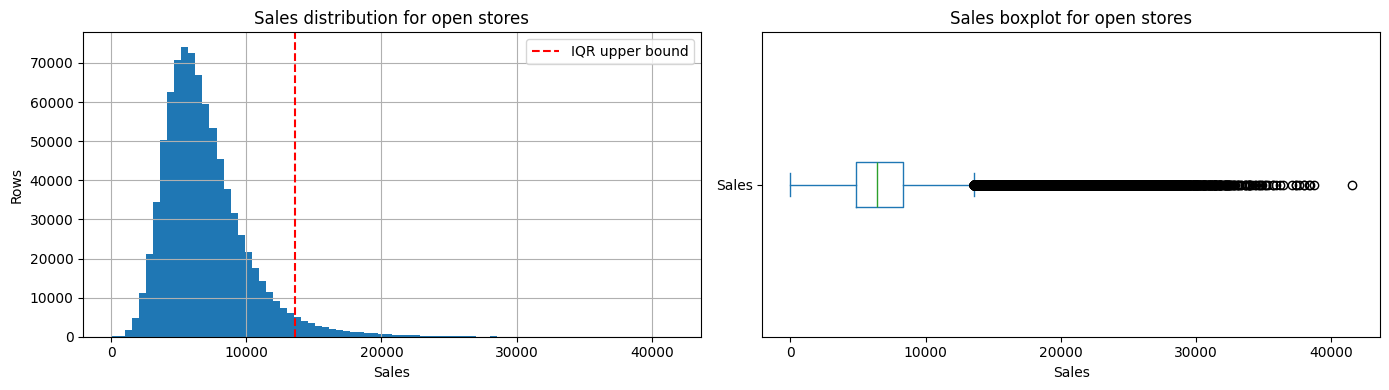

In [15]:
# Возможные выбросы в продажах
sales_all = train["Sales"]
sales_open = train.loc[train["Open"] == 1, "Sales"]

sales_summary = pd.DataFrame(
    {
        "all_rows": sales_all.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.995, 0.999]),
        "open_stores_only": sales_open.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.995, 0.999]),
    }
)

display(sales_summary)

q1 = sales_open.quantile(0.25)
q3 = sales_open.quantile(0.75)
iqr = q3 - q1
iqr_upper_bound = q3 + 1.5 * iqr

sales_outlier_report = pd.DataFrame(
    [
        {
            "method": "IQR upper bound on open stores",
            "threshold": iqr_upper_bound,
            "rows_above_threshold": (sales_open > iqr_upper_bound).sum(),
            "share_of_open_store_rows": (sales_open > iqr_upper_bound).mean(),
        },
        {
            "method": "99.5 percentile on open stores",
            "threshold": sales_open.quantile(0.995),
            "rows_above_threshold": (sales_open > sales_open.quantile(0.995)).sum(),
            "share_of_open_store_rows": (sales_open > sales_open.quantile(0.995)).mean(),
        },
        {
            "method": "99.9 percentile on open stores",
            "threshold": sales_open.quantile(0.999),
            "rows_above_threshold": (sales_open > sales_open.quantile(0.999)).sum(),
            "share_of_open_store_rows": (sales_open > sales_open.quantile(0.999)).mean(),
        },
    ]
)

display(sales_outlier_report)

print("Top sales rows:")
display(
    train.sort_values("Sales", ascending=False)
    .head(20)[
        [
            "Store",
            "Date",
            "Sales",
            "Customers",
            "Open",
            "Promo",
            "StateHoliday",
            "SchoolHoliday",
        ]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sales_open.hist(bins=80, ax=axes[0])
axes[0].axvline(iqr_upper_bound, color="red", linestyle="--", label="IQR upper bound")
axes[0].set_title("Sales distribution for open stores")
axes[0].set_xlabel("Sales")
axes[0].set_ylabel("Rows")
axes[0].legend()

sales_open.plot(kind="box", ax=axes[1], vert=False)
axes[1].set_title("Sales boxplot for open stores")
axes[1].set_xlabel("Sales")

plt.tight_layout()
plt.show()

- Так как закрытых магазинов не так много, то статистика очень схожа со статистикой по только открытым магазинам. 
- Медианное знаение продаж 6955.
- 95% наблюдений имеют Sales ниже 12668, тогда как максимальное значение - 41551.
- 845 строчек за 99.9 percentile - 1%. Скорее всего это выбросы, связанные с праздниками, акциями и тд., нужно рассмотреть детальнее. 
- Все распределение не похоже на нормальное, оно скошено вправо. Больше похоже на распределение Пуассона. 

In [16]:
# Берем только открытые магазины и строки выше IQR-порога
outliers = train.loc[
    (train["Open"] == 1) & (train["Sales"] > iqr_upper_bound)
].copy()

# Берем открытые магазины без выбросов
normal_open = train.loc[
    (train["Open"] == 1) & (train["Sales"] <= iqr_upper_bound)
].copy()

print("Outlier rows:", len(outliers))
print("Normal open rows:", len(normal_open))
print("Share of outliers among open stores:", len(outliers) / (len(outliers) + len(normal_open)))

# Сравниваем Sales и Customers у обычных строк и выбросов
print("Сравниваем Sales и Customers у обычных строк и выбросов:", "\n")
comparison_summary = pd.concat(
    {
        "normal_open_rows": normal_open[["Sales", "Customers"]].describe(),
        "sales_outliers": outliers[["Sales", "Customers"]].describe(),
    },
    axis=1
)

display(comparison_summary)

# Считаем средний чек на одного покупателя
outliers["SalesPerCustomer"] = outliers["Sales"] / outliers["Customers"]
normal_open["SalesPerCustomer"] = normal_open["Sales"] / normal_open["Customers"]

# Сравниваем средний чек у обычных строк и выбросов
sales_per_customer_summary = pd.concat(
    {
        "normal_open_rows": normal_open["SalesPerCustomer"].describe(
            percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
        ),
        "sales_outliers": outliers["SalesPerCustomer"].describe(
            percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
        ),
    },
    axis=1
)

display(sales_per_customer_summary)

# Задаем пороги для подозрительных выбросов
customers_95 = normal_open["Customers"].quantile(0.95)
spc_99 = normal_open["SalesPerCustomer"].quantile(0.99)

# Ищем строки, где Sales высокий, но Customers не очень высокий
print("Самые подозрительные строки:", "\n")
suspicious_outliers = outliers.loc[
    (outliers["Customers"] <= customers_95)
    & (outliers["SalesPerCustomer"] > spc_99)
].copy()

print("Suspicious outliers:", len(suspicious_outliers))
print("Share among sales outliers:", len(suspicious_outliers) / len(outliers))

# Показываем самые подозрительные строки
print("Строки с высокими продажами, но небольшим количеством покупателей:", "\n")
display(
    suspicious_outliers.sort_values("Sales", ascending=False)[
        [
            "Store",
            "Date",
            "Sales",
            "Customers",
            "SalesPerCustomer",
            "Promo",
            "StateHoliday",
            "SchoolHoliday",
        ]
    ].head(20)
)

# Сравниваем контекст обычных строк и выбросов
print("Контекст обычных строк и выбросов:", "\n")
context_report = pd.DataFrame(
    {
        "normal_open_rows": {
            "promo_share": normal_open["Promo"].mean(),
            "school_holiday_share": normal_open["SchoolHoliday"].mean(),
            "state_holiday_share": (normal_open["StateHoliday"].astype(str) != "0").mean(),
            "median_customers": normal_open["Customers"].median(),
            "median_sales_per_customer": normal_open["SalesPerCustomer"].median(),
        },
        "sales_outliers": {
            "promo_share": outliers["Promo"].mean(),
            "school_holiday_share": outliers["SchoolHoliday"].mean(),
            "state_holiday_share": (outliers["StateHoliday"].astype(str) != "0").mean(),
            "median_customers": outliers["Customers"].median(),
            "median_sales_per_customer": outliers["SalesPerCustomer"].median(),
        },
    }
)

display(context_report)

# Смотрим, какие магазины чаще всего попадают в выбросы
print("Магазины чаще всего попадают в выбросы:", "\n")
top_outlier_stores = (
    outliers.groupby("Store")
    .agg(
        outlier_rows=("Sales", "size"),
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
        mean_customers=("Customers", "mean"),
        median_customers=("Customers", "median"),
        promo_share=("Promo", "mean"),
        school_holiday_share=("SchoolHoliday", "mean"),
    )
    .sort_values("outlier_rows", ascending=False)
)

display(top_outlier_stores.head(20))

# Показываем топ продаж среди выбросов
print("Топ продаж среди выбросов:", "\n")
display(
    outliers.sort_values("Sales", ascending=False)[
        [
            "Store",
            "Date",
            "Sales",
            "Customers",
            "SalesPerCustomer",
            "Promo",
            "StateHoliday",
            "SchoolHoliday",
        ]
    ].head(20)
)

Outlier rows: 30769
Normal open rows: 813623
Share of outliers among open stores: 0.03643923675259832
Сравниваем Sales и Customers у обычных строк и выбросов: 



normal_open_rows                sales_outliers              
                 Sales      Customers          Sales     Customers
count    813623.000000  813623.000000   30769.000000  30769.000000
mean       6584.586333     718.850818   16763.942182   1922.980792
std        2421.524515     305.936307    3089.559200    738.786377
min           0.000000       0.000000   13612.000000    261.000000
25%        4802.000000     513.000000   14505.000000   1370.000000
50%        6253.000000     663.000000   15830.000000   1767.000000
75%        8080.000000     861.000000   18104.000000   2260.000000
max       13611.000000    4256.000000   41551.000000   7388.000000

,normal_open_rows,sales_outliers
count,813571.000000,30769.000000
mean,9.488216,9.636492
std,2.157914,3.060431
min,0.000000,3.194020
50%,9.256173,9.051047
75%,10.886647,11.338146
90%,12.430556,13.969373
95%,13.345063,15.275055
99%,15.028937,17.085728
max,51.694444,64.957854


Самые подозрительные строки: 

Suspicious outliers: 1545
Share among sales outliers: 0.050212876596574474
Строки с высокими продажами, но небольшим количеством покупателей: 



,Store,Date,Sales,Customers,SalesPerCustomer,Promo,StateHoliday,SchoolHoliday
686180,126,2013-10-24,33071,574,57.614983,1,0,1
688410,126,2013-10-22,30619,554,55.268953,1,0,1
716285,126,2013-09-27,27050,613,44.127243,1,0,0
697330,126,2013-10-14,25049,475,52.734737,0,0,0
679987,623,2013-10-30,24888,833,29.877551,0,0,1
736355,126,2013-09-09,24134,731,33.015048,1,0,0
627958,999,2013-12-16,23650,1263,18.725257,1,0,0
18681,842,2015-07-15,23523,1204,19.537375,1,0,0
834697,348,2013-06-13,23379,1088,21.488051,0,0,0
46623,909,2015-06-20,22882,1214,18.848435,0,0,0


...

,normal_open_rows,sales_outliers
promo_share,0.435879,0.723293
school_holiday_share,0.192302,0.227372
state_holiday_share,0.000930,0.004973
median_customers,663.000000,1767.000000
median_sales_per_customer,9.256173,9.051047


Магазины чаще всего попадают в выбросы: 



,outlier_rows,mean_sales,median_sales,mean_customers,median_customers,promo_share,school_holiday_share
Store,,,,,,,
262,940,20734.256383,19418.0,3404.381915,3240.0,0.382979,0.178723
562,869,18414.295742,18293.0,3157.092060,3151.0,0.414269,0.215190
1114,779,20733.586650,20431.0,3212.062901,3183.0,0.453145,0.197689
251,769,19221.323797,18633.0,2461.853056,2394.0,0.455137,0.196359
788,759,18134.600791,17595.0,1731.372859,1722.0,0.465086,0.194993
513,754,18417.944297,17938.5,2118.807692,2084.0,0.466844,0.196286
817,747,22231.368139,22034.0,3193.615797,3201.0,0.472557,0.207497
383,727,17621.116919,17339.0,2236.016506,2218.0,0.480055,0.198074
733,723,15604.947441,15383.0,3498.002766,3461.0,0.471646,0.160443


Топ продаж среди выбросов: 



,Store,Date,Sales,Customers,SalesPerCustomer,Promo,StateHoliday,SchoolHoliday
44393,909,2015-06-22,41551,1721,24.143521,0,0,0
132946,262,2015-04-03,38722,5132,7.545207,1,b,0
101726,262,2015-05-01,38484,5458,7.050934,1,a,0
87231,262,2015-05-14,38367,5192,7.389638,0,a,1
424086,57,2014-06-16,38037,1970,19.308122,1,0,0
627776,817,2013-12-16,38025,4381,8.679525,1,0,0
627220,261,2013-12-16,37646,1964,19.168024,1,0,0
444361,262,2014-05-29,37403,5297,7.061167,0,a,0
620531,262,2013-12-22,37376,4916,7.602929,0,0,0
245945,262,2014-12-21,37122,4962,7.481258,0,0,0


- У выбросов гораздо больше клиентов. median_customers	= 1767 (по сравнению с 663)
- Среднее количество покупок на покупателя не сильно отличается, однако есть счастливые дни, например, у магазина 909 (см. последнюю таблицу).
- Среди выбросов гораздо выше процент дней с state_holiday_share, school_holiday_share и promo_share.

## Общий вывод по качеству данных

- В train доступны данные за период **2013-01-01 — 2015-07-31**: всего **942 календарных дня**.
- В train и store одинаковое количество магазинов: **1115**, значит справочник `store` покрывает все магазины из обучающей выборки.
- Полная сетка `Store × Date` должна содержать **1,050,330** строк, фактически в train — **1,017,209** строк. Отсутствует **33,121 строка**, то есть около **3.15%**.
- У **181 магазина** есть хотя бы одна пропущенная дата. Основной паттерн пропусков системный: **180 магазинов отсутствуют с 2014-07-01 по 2014-12-31**, всего **184 дня**.
- По дням недели пропуски распределены почти равномерно, а по месяцам почти полностью сосредоточены во втором полугодии **2014 года**. Значит, это не случайный шум, а структурный пропуск по периоду/группе магазинов.
- Около **16.2% магазинов** имеют меньше 942 наблюдений, но уже нижний квартиль по числу наблюдений равен полному периоду, значит большинство магазинов имеют полную историю.
- Удалять магазины с неполной историей или обрезать все магазины до общего короткого периода не стоит: так потеряется много полезных наблюдений.
- Для моделирования истории достаточно для признаков `lag(7/14/28)` и `rolling mean(7/14/28)`. Для неполных рядов лучше использовать `min_periods`, флаги доступности лагов и аккуратную time-based validation.

**Пропуски в признаках**

- В test есть **11 пропусков в `Open`**. Их очень мало, поэтому на baseline-этапе их можно обработать простым правилом или удалить из анализа.
- В `store` есть пропуски в `CompetitionOpenSinceMonth` и `CompetitionOpenSinceYear`; они синхронные, то есть если нет года, то обычно нет и месяца.
- Эти пропуски, скорее всего, означают отсутствие информации о дате открытия конкурента или отсутствие конкурента. На этапе EDA их лучше не заполнять искусственными датами.
- Для конкурентов стоит добавить флаг `Competition_is_missing`, а далее при feature engineering аккуратно считать длительность конкуренции только там, где дата известна.
- В `Promo2SinceWeek`, `Promo2SinceYear`, `PromoInterval` пропуски также синхронные и соответствуют магазинам, где `Promo2 == 0`. Поэтому пока их можно не заполнять: основной индикатор уже есть в колонке `Promo2`.

**Логические проверки и аномалии**

- Логических противоречий вида “магазин закрыт, но есть продажи” не обнаружено.
- Около **17% строк train** — дни, когда магазин был закрыт. Почти такая же доля строк имеет `Sales = 0`.
- Есть **54 случая**, когда магазин был открыт, но продажи равны нулю. Это редкие аномалии, которые стоит оставить и учитывать в модели.
- Есть **2 случая**, когда были покупатели (`Customers > 0`), но продаж не было. Такие строки редкие и требуют внимания, но их слишком мало для агрессивного удаления.

**Продажи и выбросы**

- Распределение `Sales` по открытым магазинам скошено вправо: основная масса наблюдений находится в умеренном диапазоне, но есть длинный правый хвост с очень высокими продажами.
- Медианное значение продаж по открытым магазинам — около **6955**.
- **95% наблюдений** имеют `Sales` ниже примерно **12668**, при этом максимум достигает **41551**.
- Значения выше верхних перцентилей и IQR-порога формально выглядят как выбросы, но не обязательно являются ошибками.
- У строк с высокими продажами заметно больше клиентов: медиана `Customers` среди выбросов около **1767** против **663** у обычных открытых дней.
- `SalesPerCustomer` у выбросов в целом не выглядит радикально отличающимся, значит высокие продажи в основном объясняются большим потоком покупателей, а не подозрительно большим средним чеком.
- Среди выбросов выше доля `Promo`, `StateHoliday` и `SchoolHoliday`, поэтому высокие продажи хорошо объясняются бизнес-контекстом: акции, праздники, каникулы и сезонные эффекты.
- Автоматически удалять большие значения `Sales` не стоит. Лучше оставить их в данных и при моделировании рассмотреть логарифмирование таргета через `log1p(Sales)`.

Отсутствуют данные о магазинах в определенный период, может там был ремонт или что-то пошло не так. Пропуски в середине, поэтому пока что можно их для EDA оставить так, но иметь в виду.

## Оценка разметки

- Задача является supervised learning: целевая переменная уже присутствует в данных и задаётся колонкой `Sales`.
- Разметка формируется автоматически как факт исторических продаж магазина за конкретный день, поэтому ручная доразметка не требуется.
- Качество таргета зависит не от субъективной ручной разметки, а от корректности первичного учёта продаж в бизнес-системах.
- В данных есть ожидаемые нулевые продажи: около 17% строк относятся к дням, когда магазин был закрыт, и почти такая же доля строк имеет `Sales = 0`.
- Логических противоречий вида “магазин закрыт, но есть продажи” не обнаружено.
- Обнаружены редкие аномальные случаи: открытый магазин с нулевыми продажами, а также несколько строк, где были покупатели, но не было продаж. Таких наблюдений мало, поэтому их не стоит удалять автоматически, но они могут вносить шум в таргет.
- Высокие значения `Sales` формально выглядят как выбросы, однако в основном объясняются большим количеством покупателей, промоакциями, праздниками и школьными каникулами.
- Следовательно, экстремально высокие продажи скорее отражают реальные бизнес-события, а не ошибки разметки.
- Возможный шум в таргете связан с закрытыми днями, редкими аномалиями, промоакциями, праздниками, сезонностью и внешними факторами, которые не полностью представлены в датасете.
- В целом таргет `Sales` пригоден для обучения модели, но при моделировании стоит учитывать скошенное распределение продаж, нулевые значения и редкие экстремальные пики.

Проверим стабильность таргета.

In [17]:
# Проверяем стабильность Sales по магазинам
store_sales_stability = (
    train.loc[train["Open"] == 1]
    .groupby("Store")
    .agg(
        rows=("Sales", "size"),
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
        std_sales=("Sales", "std"),
        min_sales=("Sales", "min"),
        max_sales=("Sales", "max"),
        zero_sales_share=("Sales", lambda x: (x == 0).mean()),
    )
)

# Коэффициент вариации: чем выше, тем менее стабильны продажи магазина
store_sales_stability["cv_sales"] = (
    store_sales_stability["std_sales"] / store_sales_stability["mean_sales"]
)

display(
    store_sales_stability[
        [
            "rows",
            "mean_sales",
            "median_sales",
            "std_sales",
            "cv_sales",
            "min_sales",
            "max_sales",
            "zero_sales_share",
        ]
    ].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
)

# Магазины с самой высокой относительной нестабильностью продаж
display(
    store_sales_stability
    .sort_values("cv_sales", ascending=False)
    .head(15)
)

,rows,mean_sales,median_sales,std_sales,cv_sales,min_sales,max_sales,zero_sales_share
count,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000
mean,757.302242,6934.208449,6674.630942,1846.231022,0.271655,2794.534529,15368.395516,0.000063
std,63.861126,2383.911051,2314.513962,623.321567,0.058465,1506.720077,5357.464254,0.000346
min,592.000000,2703.736573,2293.000000,575.952359,0.123084,0.000000,5759.000000,0.000000
25%,776.000000,5322.299969,5106.250000,1402.994203,0.232723,1845.000000,11700.000000,0.000000
50%,779.000000,6589.948470,6332.000000,1773.281547,0.264061,2644.000000,14531.000000,0.000000
75%,782.000000,7964.200644,7622.750000,2154.096465,0.301315,3547.500000,17944.000000,0.000000
90%,784.000000,9677.075676,9307.800000,2638.653175,0.351532,4560.800000,22038.400000,0.000000
95%,784.000000,11019.012503,10581.450000,3024.242300,0.384969,5543.000000,25521.600000,0.000000
99%,931.860000,15474.795453,14966.980000,3747.779649,0.435106,7416.120000,32745.540000,0.002423


,rows,mean_sales,median_sales,std_sales,min_sales,max_sales,zero_sales_share,cv_sales
Store,,,,,,,,
198,782,2900.604859,2526.0,1597.761904,530,10676,0.000000,0.550837
897,778,3492.944730,3267.5,1810.461801,1095,20167,0.000000,0.518320
607,782,3901.910486,3600.0,1879.566980,695,10794,0.000000,0.481704
126,779,6507.753530,5919.0,3049.536739,1025,33071,0.000000,0.468601
575,623,5367.566613,4613.0,2472.728592,1849,17313,0.000000,0.460680
708,688,4571.989826,4287.5,2070.314067,0,24975,0.001453,0.452826
589,757,4672.622193,4341.0,2113.234629,0,19781,0.001321,0.452259
543,781,2790.380282,2293.0,1237.698497,506,8754,0.000000,0.443559
876,766,9228.909922,9042.0,4079.722505,1740,27330,0.000000,0.442059


- Стабильность `Sales` по магазинам в целом выглядит приемлемо: медианный коэффициент вариации `cv_sales` равен **0.264**, то есть для типичного магазина стандартное отклонение продаж составляет около **26% от среднего уровня продаж**.
- У большинства магазинов разброс продаж умеренный: у 75% магазинов `cv_sales` ниже **0.301**, у 95% — ниже **0.385**.
- При этом есть небольшая группа более нестабильных магазинов: максимальный `cv_sales` достигает **0.551**. Это означает, что у отдельных магазинов продажи сильно колеблются относительно их среднего уровня.
- Средние продажи сильно отличаются между магазинами: медианное значение `mean_sales` около **6590**, но максимум по средним продажам достигает **21757**. Значит, магазины имеют разный масштаб, и модель должна учитывать индивидуальные особенности магазинов.
- Нулевые продажи среди открытых дней почти отсутствуют: медианная доля `zero_sales_share` равна **0**, а максимум всего около **0.39%**. Это подтверждает, что открытые дни с нулевыми продажами — редкие аномалии, а не массовая проблема качества таргета.
- Самые нестабильные магазины имеют высокий `cv_sales`, но это не обязательно ошибка разметки: колебания могут быть связаны с промо, праздниками, сезонностью, разным потоком покупателей и локальными особенностями магазинов.
- Вывод: таргет `Sales` по магазинам достаточно стабильный для supervised learning, но между магазинами есть выраженная неоднородность. Поэтому в модели важно использовать признаки магазина, календарные признаки, промо-факторы и лаговые/rolling-признаки.

## Bias / дисбаланс

In [18]:
# Анализируем только открытые дни
open_train = train.loc[train["Open"] == 1].copy()

# Считаем статистику продаж по каждому магазину
store_bias_report = (
    open_train
    .groupby("Store")
    .agg(
        rows=("Sales", "size"),
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
        std_sales=("Sales", "std"),
        min_sales=("Sales", "min"),
        max_sales=("Sales", "max"),
    )
)

# Коэффициент вариации: относительная нестабильность продаж
store_bias_report["cv_sales"] = (
    store_bias_report["std_sales"] / store_bias_report["mean_sales"]
)

print("Stores:", store_bias_report.shape[0])
print("Median rows per store:", store_bias_report["rows"].median())
print("Min rows per store:", store_bias_report["rows"].min())
print("Max rows per store:", store_bias_report["rows"].max())

print("\nMean Sales by store:")
print(store_bias_report["mean_sales"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

print("\nCV Sales by store:")
print(store_bias_report["cv_sales"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

Stores: 1115
Median rows per store: 779.0
Min rows per store: 592
Max rows per store: 942

Mean Sales by store:
count     1115.000000
mean      6934.208449
std       2383.911051
min       2703.736573
25%       5322.299969
50%       6589.948470
75%       7964.200644
95%      11019.012503
99%      15474.795453
max      21757.483418
Name: mean_sales, dtype: float64

CV Sales by store:
count    1115.000000
mean        0.271655
std         0.058465
min         0.123084
25%         0.232723
50%         0.264061
75%         0.301315
95%         0.384969
99%         0.435106
max         0.550837
Name: cv_sales, dtype: float64


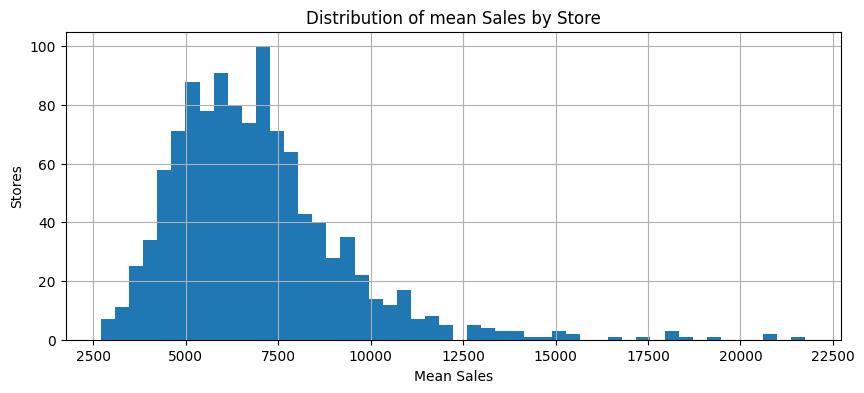

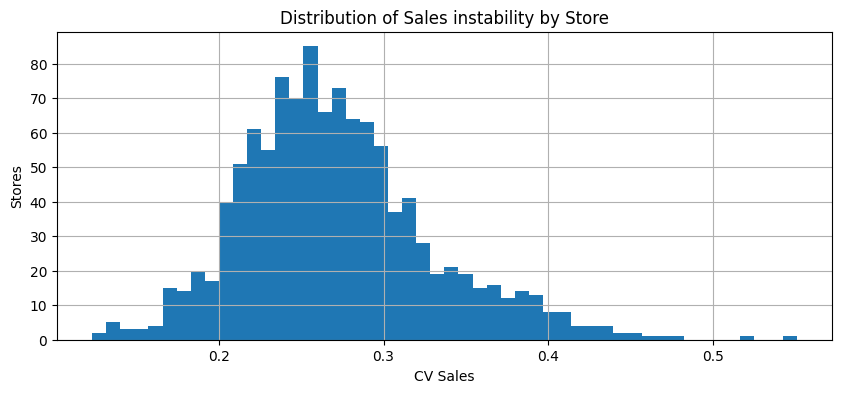

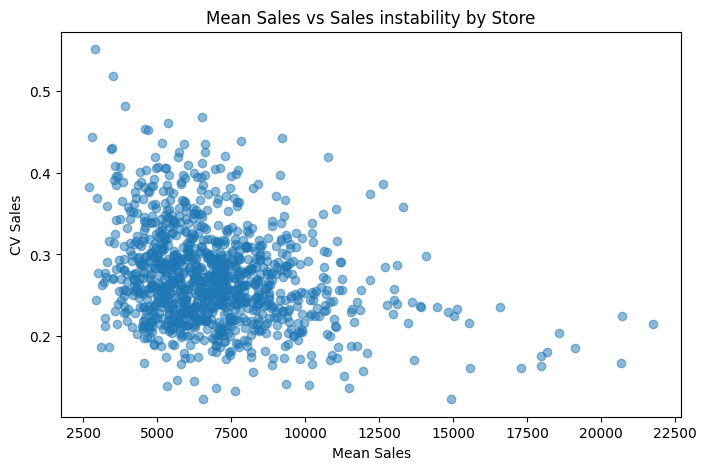

In [19]:
# Распределение средних продаж по магазинам
plt.figure(figsize=(10, 4))
store_bias_report["mean_sales"].hist(bins=50)
plt.title("Distribution of mean Sales by Store")
plt.xlabel("Mean Sales")
plt.ylabel("Stores")
plt.show()

# Распределение нестабильности продаж по магазинам
plt.figure(figsize=(10, 4))
store_bias_report["cv_sales"].hist(bins=50)
plt.title("Distribution of Sales instability by Store")
plt.xlabel("CV Sales")
plt.ylabel("Stores")
plt.show()

# Связь среднего уровня продаж и нестабильности
plt.figure(figsize=(8, 5))
plt.scatter(
    store_bias_report["mean_sales"],
    store_bias_report["cv_sales"],
    alpha=0.5
)
plt.title("Mean Sales vs Sales instability by Store")
plt.xlabel("Mean Sales")
plt.ylabel("CV Sales")
plt.show()

- В данных есть **1115 магазинов**. Медианное число наблюдений на магазин — **779 открытых дней**, минимум — **592**, максимум — **942**. Это подтверждает, что история по магазинам не полностью одинаковая: часть магазинов имеет более короткий период наблюдений.
- Средние продажи сильно различаются между магазинами: медианное значение `mean_sales` около **6589**, но минимум около **2704**, а максимум — **21757**. Значит, магазины имеют разный масштаб продаж, и модель должна учитывать идентификатор магазина и признаки магазина.
- Коэффициент вариации `cv_sales` показывает относительную нестабильность продаж. У типичного магазина `cv_sales` около **0.264**, то есть разброс продаж умеренный.
- У большинства магазинов нестабильность не слишком высокая: у 75% магазинов `cv_sales` ниже **0.301**. Но есть отдельные более нестабильные магазины, где `cv_sales` доходит до **0.551**.

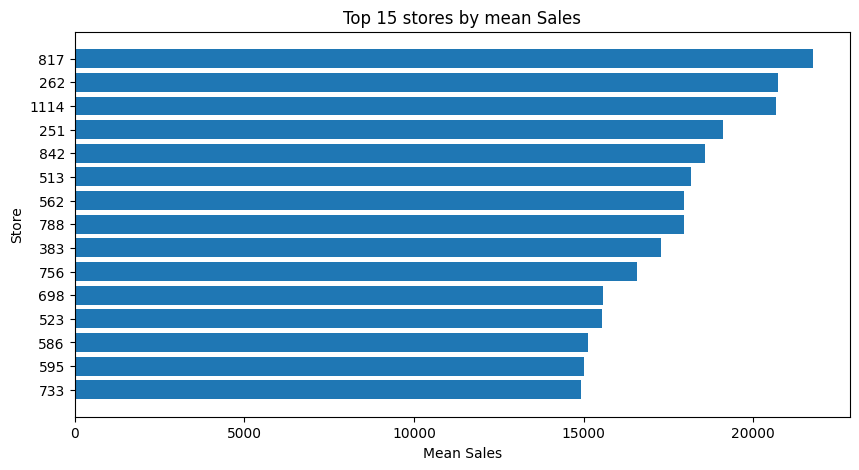

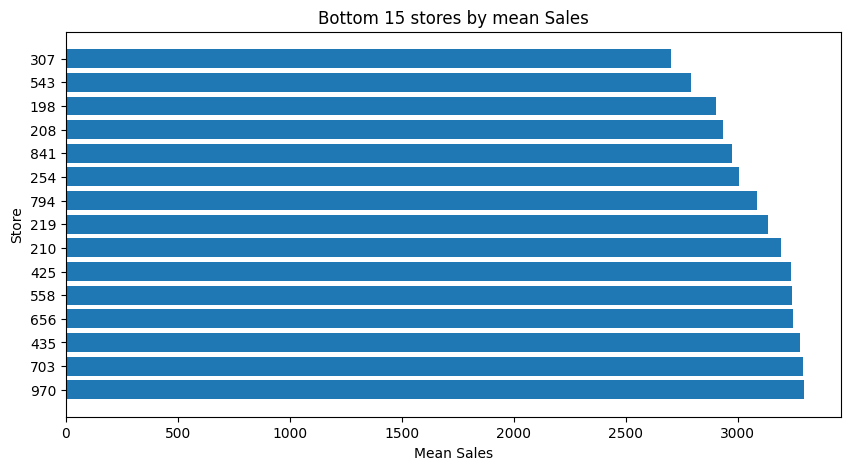

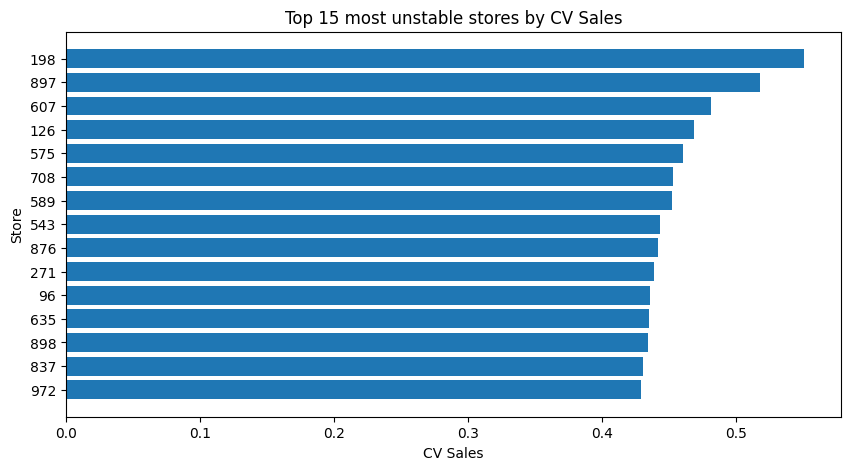

In [20]:
# Топ магазинов по средним продажам
top_mean_sales = (
    store_bias_report
    .sort_values("mean_sales", ascending=False)
    .head(15)
    .sort_values("mean_sales")
)

plt.figure(figsize=(10, 5))
plt.barh(top_mean_sales.index.astype(str), top_mean_sales["mean_sales"])
plt.title("Top 15 stores by mean Sales")
plt.xlabel("Mean Sales")
plt.ylabel("Store")
plt.show()

# Магазины с самыми низкими средними продажами
low_mean_sales = (
    store_bias_report
    .sort_values("mean_sales", ascending=True)
    .head(15)
    .sort_values("mean_sales", ascending=False)
)

plt.figure(figsize=(10, 5))
plt.barh(low_mean_sales.index.astype(str), low_mean_sales["mean_sales"])
plt.title("Bottom 15 stores by mean Sales")
plt.xlabel("Mean Sales")
plt.ylabel("Store")
plt.show()

# Самые нестабильные магазины
top_unstable = (
    store_bias_report
    .sort_values("cv_sales", ascending=False)
    .head(15)
    .sort_values("cv_sales")
)

plt.figure(figsize=(10, 5))
plt.barh(top_unstable.index.astype(str), top_unstable["cv_sales"])
plt.title("Top 15 most unstable stores by CV Sales")
plt.xlabel("CV Sales")
plt.ylabel("Store")
plt.show()

,rows,stores,mean_sales,median_sales
StoreType,,,,
b,15563,17,10231.407505,9130.0
c,112978,148,6932.512755,6407.0
a,457077,602,6925.167661,6285.0
d,258774,348,6822.141881,6395.0


<Figure size 800x500 with 0 Axes>

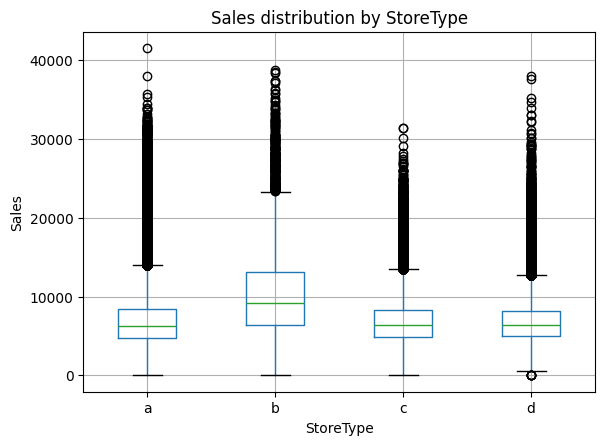

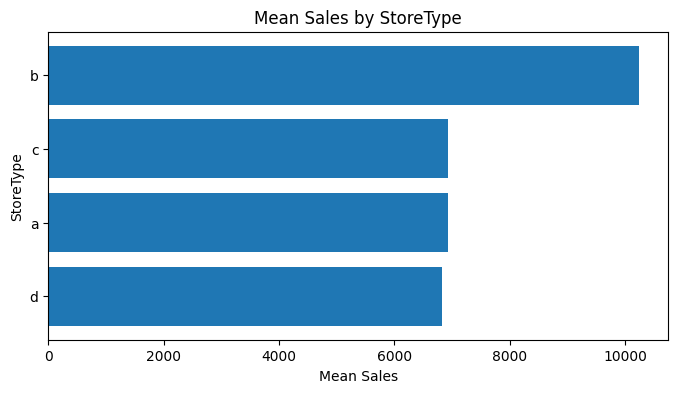

In [21]:
# Добавляем признаки магазина к train
train_store = train.merge(store, on="Store", how="left")

# Оставляем только открытые дни
open_train_store = train_store.loc[train_store["Open"] == 1].copy()

# Продажи по StoreType
store_type_report = (
    open_train_store
    .groupby("StoreType")
    .agg(
        rows=("Sales", "size"),
        stores=("Store", "nunique"),
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
    )
    .sort_values("mean_sales", ascending=False)
)

display(store_type_report)

# Визуализация продаж по StoreType
plt.figure(figsize=(8, 5))
open_train_store.boxplot(column="Sales", by="StoreType")
plt.title("Sales distribution by StoreType")
plt.suptitle("")
plt.xlabel("StoreType")
plt.ylabel("Sales")
plt.show()

# Средние продажи по StoreType
store_type_plot = store_type_report.sort_values("mean_sales")

plt.figure(figsize=(8, 4))
plt.barh(store_type_plot.index.astype(str), store_type_plot["mean_sales"])
plt.title("Mean Sales by StoreType")
plt.xlabel("Mean Sales")
plt.ylabel("StoreType")
plt.show()

- По `StoreType` видно, что тип **b** имеет самые высокие средние и медианные продажи: `mean_sales` около **10231**, `median_sales` около **9130**. Однако таких магазинов всего **17**, поэтому этот тип представлен слабо.
- Типы магазинов **a**, **c** и **d** имеют похожий уровень средних продаж, но отличаются количеством магазинов и наблюдений. Это значит, что `StoreType` может быть полезным признаком, но важно учитывать дисбаланс по числу магазинов каждого типа.

,rows,stores,mean_sales,median_sales
Assortment,,,,
b,8212,9,8639.346322,8081.0
c,391271,513,7300.526339,6675.0
a,444909,593,6621.017039,6082.0


<Figure size 800x500 with 0 Axes>

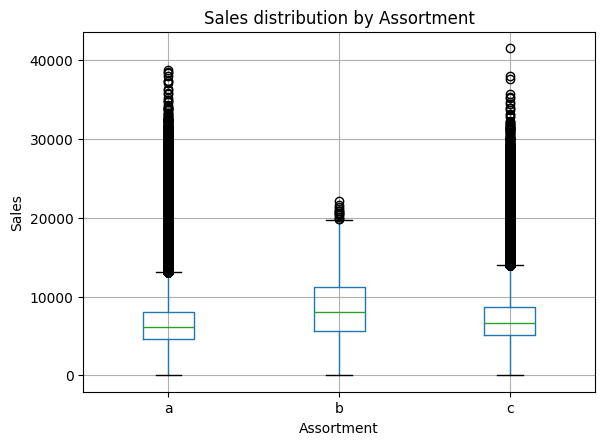

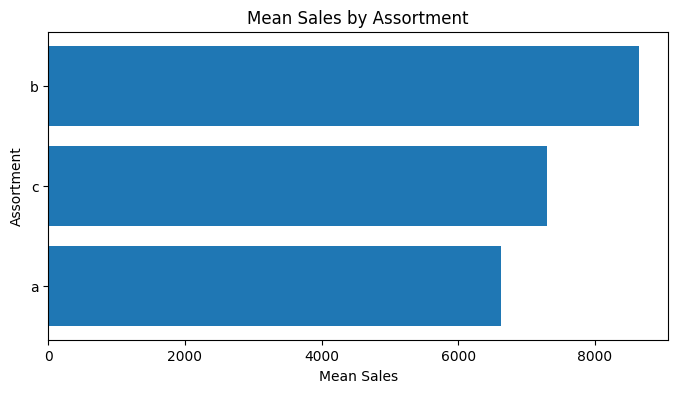

In [22]:
# Продажи по Assortment
assortment_report = (
    open_train_store
    .groupby("Assortment")
    .agg(
        rows=("Sales", "size"),
        stores=("Store", "nunique"),
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
    )
    .sort_values("mean_sales", ascending=False)
)

display(assortment_report)

# Визуализация продаж по Assortment
plt.figure(figsize=(8, 5))
open_train_store.boxplot(column="Sales", by="Assortment")
plt.title("Sales distribution by Assortment")
plt.suptitle("")
plt.xlabel("Assortment")
plt.ylabel("Sales")
plt.show()

# Средние продажи по Assortment
assortment_plot = assortment_report.sort_values("mean_sales")

plt.figure(figsize=(8, 4))
plt.barh(assortment_plot.index.astype(str), assortment_plot["mean_sales"])
plt.title("Mean Sales by Assortment")
plt.xlabel("Mean Sales")
plt.ylabel("Assortment")
plt.show()

- По `Assortment` самый высокий уровень продаж у типа **b**: `mean_sales` около **8639**, `median_sales` около **8081**. Но таких магазинов всего **9**, поэтому вывод по этому типу менее устойчивый.
- Ассортимент **c** в среднем продает больше, чем **a**: около **7301** против **6621** по средним продажам. Значит, `Assortment` тоже стоит использовать как признак в модели.

Sales skew: 1.5939220392699807
log1p(Sales) skew: -0.6379710294195984


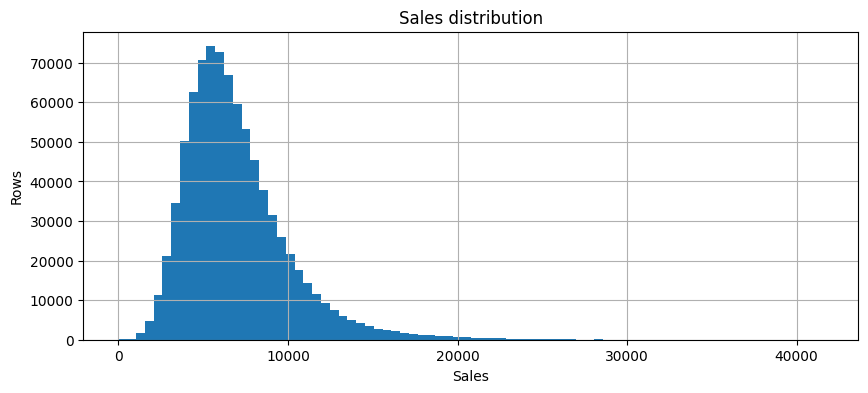

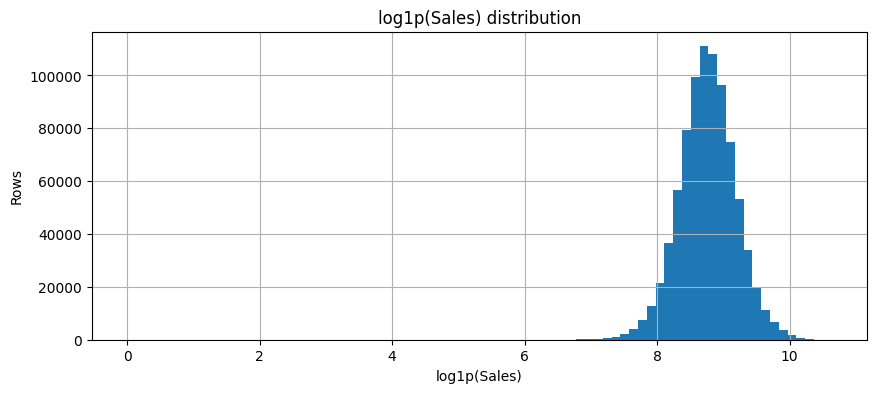

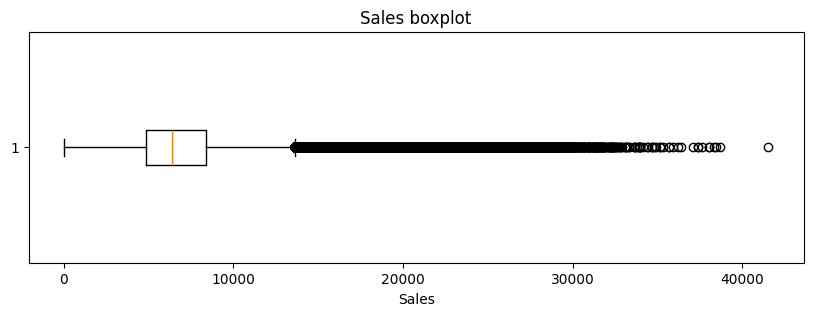

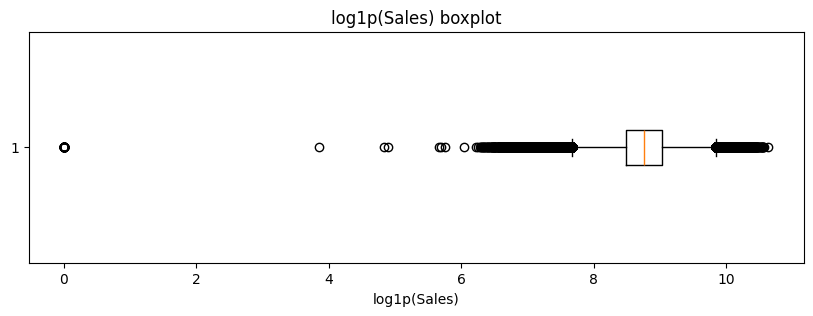

In [23]:
# Сравниваем Sales и log1p(Sales)
sales_log = np.log1p(open_train["Sales"])

print("Sales skew:", open_train["Sales"].skew())
print("log1p(Sales) skew:", sales_log.skew())

# Визуально сравниваем Sales и log1p(Sales)
plt.figure(figsize=(10, 4))
open_train["Sales"].hist(bins=80)
plt.title("Sales distribution")
plt.xlabel("Sales")
plt.ylabel("Rows")
plt.show()

plt.figure(figsize=(10, 4))
sales_log.hist(bins=80)
plt.title("log1p(Sales) distribution")
plt.xlabel("log1p(Sales)")
plt.ylabel("Rows")
plt.show()

# Boxplot для Sales
plt.figure(figsize=(10, 3))
plt.boxplot(open_train["Sales"], vert=False)
plt.title("Sales boxplot")
plt.xlabel("Sales")
plt.show()

# Boxplot для log1p(Sales)
plt.figure(figsize=(10, 3))
plt.boxplot(sales_log, vert=False)
plt.title("log1p(Sales) boxplot")
plt.xlabel("log1p(Sales)")
plt.show()

- Скошенность исходного таргета `Sales` равна **1.59**, что подтверждает сильную правостороннюю асимметрию: есть длинный хвост высоких продаж.
- После преобразования `log1p(Sales)` скошенность становится **-0.64**. Распределение становится заметно более симметричным, хотя появляется умеренная левосторонняя асимметрия.
- Это подтверждает, что логарифмирование таргета имеет смысл протестировать при моделировании: оно снижает влияние экстремально высоких продаж и может сделать обучение более устойчивым.
- При этом `log1p(Sales)` не обязательно должен быть финальным вариантом таргета: его стоит сравнить с обучением на исходном `Sales` по time-based validation.



### Общий вывод по блоку

- В задаче нет классического class imbalance, так как таргет `Sales` числовой, но есть выраженный **структурный дисбаланс**.
- Магазины сильно отличаются по среднему уровню продаж, поэтому модель без признаков магазина будет смешивать магазины разного масштаба.
- История по магазинам неодинаковая: часть магазинов имеет меньше наблюдений, поэтому при построении lag/rolling-признаков нужно аккуратно учитывать доступность истории.
- Распределение продаж скошено вправо, поэтому для обучения стоит рассмотреть `log1p(Sales)`, чтобы снизить влияние экстремально высоких значений.
- `StoreType` и `Assortment` связаны с уровнем продаж, поэтому эти признаки нужно использовать в модели.
- Типы `StoreType = b` и `Assortment = b` показывают более высокие продажи, но представлены малым числом магазинов, поэтому по ним возможен дисбаланс и риск переобучения.
- Экстремально нестабильные магазины на baseline-этапе лучше не исключать: их поведение может быть связано с реальными бизнес-факторами, такими как промо, праздники, сезонность и локальный спрос.
- Вместо удаления нестабильных рядов лучше добавить признаки магазина, календарные признаки, промо-признаки, лаги и rolling-статистики.

# Алгоритм подготовки выборки

Так как задача является forecasting-задачей, модель будет предсказывать будущие продажи `Sales` для конкретного магазина, но обучаться на общей истории всех магазинов. Поэтому датасет нужно готовить как панель временных рядов: одна строка — это один магазин в один день.

1. **Загрузить исходные данные**
   - загрузить `train.csv`;
   - загрузить `store.csv`;
   - проверить количество магазинов в обеих таблицах.

2. **Объединить данные**
   - объединить `train` и `store` по ключу `Store`;
   - использовать `left join`, чтобы сохранить все строки из `train`.

3. **Привести дату к правильному типу**
   - преобразовать колонку `Date` в `datetime`;
   - отсортировать данные по `Store` и `Date`.

4. **Обработать закрытые магазины**
   - строки с `Open == 0` и `Sales == 0` являются логичными закрытыми днями;
   - для baseline-модели можно обучаться только на открытых магазинах, чтобы модель прогнозировала спрос в дни работы;
   - закрытые дни можно обрабатывать отдельным правилом: если магазин закрыт, прогноз `Sales = 0`;
   - редкие случаи `Open == 1` и `Sales == 0` не удалять автоматически, так как они могут нести полезную информацию.

5. **Обработать пропуски**
   - пропуски в `CompetitionOpenSinceMonth` и `CompetitionOpenSinceYear` не заполнять медианами, а добавить флаг `Competition_is_missing`;
   - при генерации признаков конкуренции считать длительность конкуренции только там, где дата открытия конкурента известна;
   - пропуски в `Promo2SinceWeek`, `Promo2SinceYear`, `PromoInterval` интерпретировать через `Promo2`: если `Promo2 == 0`, магазин не участвует в длительной промоакции;
   - пропуски в календарной сетке `Store × Date` не заполнять синтетическими продажами, а учитывать их при построении лагов и rolling-признаков.

6. **Сгенерировать календарные признаки**
   - `year`;
   - `month`;
   - `week`;
   - `day`;
   - `dayofweek`;
   - `is_weekend`;
   - дополнительные признаки: начало/конец месяца, квартал, сезонность.

7. **Сгенерировать лаговые признаки по каждому магазину**
   - `lag_1`;
   - `lag_7`;
   - `lag_14`;
   - `lag_28`;
   - лаги обязательно считать внутри каждого `Store`, чтобы не смешивать разные магазины;
   - при наличии пропусков в истории учитывать, что лаг может быть недоступен.

8. **Сгенерировать rolling-признаки по каждому магазину**
   - `rolling_mean_7`;
   - `rolling_mean_14`;
   - `rolling_mean_28`;
   - `rolling_std_7`;
   - `rolling_std_14`;
   - `rolling_std_28`;
   - rolling-признаки считать только по прошлым значениям, без использования текущего дня, чтобы избежать data leakage;
   - использовать `min_periods`, чтобы не терять слишком много строк в начале истории.

9. **Добавить признаки промо, праздников и магазина**
   - использовать `Promo`, `Promo2`, `PromoInterval`;
   - использовать `StateHoliday`, `SchoolHoliday`;
   - использовать признаки из `store`: `StoreType`, `Assortment`, `CompetitionDistance`;
   - добавить признаки, связанные с конкуренцией, например длительность присутствия конкурента в месяцах.

10. **Выделить таргет**
    - основной таргет: `Sales`;
    - дополнительно протестировать вариант `log1p(Sales)`, так как распределение продаж скошено вправо;
    - при обучении на `log1p(Sales)` итоговый прогноз нужно возвращать в исходную шкалу через `expm1`.

11. **Финальная логика прогноза**
    - модель обучается на всех магазинах сразу, используя `Store` и признаки магазина для различения рядов;
    - прогноз строится для конкретного магазина и конкретных будущих дат;
    - если в будущую дату магазин закрыт, прогноз можно задавать правилом `Sales = 0`;
    - если магазин открыт, прогноз строится моделью на основе календарных, промо, store-level, lag и rolling-признаков.

**Итог**

- Выборка готовится как общий датасет по всем магазинам, но с обязательным сохранением структуры временного ряда внутри каждого `Store`.
- Основные признаки для модели: календарные признаки, признаки магазина, промо и праздники, лаги и rolling-статистики.
- Закрытые дни лучше обрабатывать отдельно, потому что они формируют нулевые продажи по бизнес-правилу, а не по спросу.
- Логарифмирование таргета `log1p(Sales)` стоит протестировать, так как оно уменьшает влияние экстремально высоких продаж.

# Стратегия валидации

Так как задача является forecasting-задачей, обычный `random split` использовать нельзя. Временной ряд имеет причинную структуру: модель должна обучаться только на прошлом и предсказывать будущее. Если случайно перемешать строки, в train могут попасть наблюдения из будущего относительно validation, что приведет к data leakage и завышенной оценке качества.

**Основная стратегия**

- Данные нужно делить **по времени**, а не случайно.
- Train должен содержать более ранний период.
- Validation должен идти сразу после train.
- Test / final holdout должен быть самым поздним доступным периодом.
- Все модели нужно сравнивать на одном и том же validation-периоде, чтобы сравнение было честным.

**Выбранная схема**

Для этой задачи можно использовать схему, близкую к исходной задаче Kaggle Rossmann:

- **train**: вся история до последних 6 недель;
- **validation**: последние 6 недель обучающего периода;
- **test / holdout**: самый поздний период, который не используется при подборе модели.

Горизонт в **6 недель** выбран потому, что он близок к реальному горизонту прогнозирования в исходной задаче. Такая валидация показывает, насколько хорошо модель сможет предсказывать продажи на ближайшие будущие недели.